In [1]:
import json

import numpy as np


def load_binary(filename: str) -> bytes:
    data = open(filename, "rb").read()
    # return np.frombuffer(data, dtype=np.uint8)
    return data


data_all_ones = load_binary("all_ones.bin")
data_all_zeros = load_binary("all_zeros.bin")
data_half_zeros_half_ones = load_binary("half_zeros_half_ones.bin")
data_ramp = load_binary("ramp.bin")
data_toggle = load_binary("toggle.bin")
# data_real = load_binary("20251211_134153.bin")

config = json.load(open("config.json"))

In [2]:
assert len(data_all_ones) == len(data_all_zeros) == len(data_half_zeros_half_ones) == len(data_ramp) == len(data_toggle)

num_bytes = len(data_all_ones)

num_bytes

80040

In [3]:
fifo_depth = config["fpga"]["fifo_depth"]
num_shots = config["fpga"]["num_shots"]
num_frames = config["num_frames"]
lvds_lanes = config["fpga"]["lvds_lanes"]

fifo_depth, num_shots, num_frames, lvds_lanes

(2048, 10, 1, [0])

In [4]:
bytes_per_shot = fifo_depth * 2 * 10 / 8 * len(lvds_lanes)

bytes_per_shot, bytes_per_shot * num_shots * num_frames

(5120.0, 51200.0)

In [5]:
np.unpackbits(np.frombuffer(data_all_ones, dtype=np.uint8), axis=-1, bitorder='big').reshape((len(lvds_lanes), -1))

array([[0, 0, 0, ..., 1, 1, 1]], shape=(1, 640320), dtype=uint8)

In [6]:
def hexdump(data: np.ndarray | bytes, binary: bool = False):
    for i in range(0, len(data), 16 if not binary else 8):
        chunk = data[i:i+16]
        if not binary:
            hex_bytes = ' '.join(f'{b:02X}' for b in chunk)
        else:
            hex_bytes = ' '.join(f'{b:08b}' for b in chunk)
        ascii_bytes = ''.join((chr(b) if 32 <= b < 127 else '.') for b in chunk)
        print(f'{i:08X}  {hex_bytes:<48}  |{ascii_bytes}|')

# START_IDX = 3190 * 10 // 8
# END_IDX = 3210 * 10 // 8
START_IDX = 0
END_IDX = 32

print("All Ones:")
hexdump(data_all_ones[START_IDX:END_IDX])
print("All Zeros:")
hexdump(data_all_zeros[START_IDX:END_IDX])
print("Half Zeros Half Ones:")
hexdump(data_half_zeros_half_ones[START_IDX:END_IDX])
print("Ramp:")
hexdump(data_ramp[START_IDX:END_IDX])
print("Toggle:")
hexdump(data_toggle[START_IDX:END_IDX])
# print("Real Data:")
# hexdump(data_real[START_IDX:END_IDX])

All Ones:
00000000  00 00 FF FF FF FF FF FF FF FF FF FF FF FF FF FF   |................|
00000010  FF FF FF FF FF FF FF FF FF FF FF FF FF FF FF FF   |................|
All Zeros:
00000000  00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00   |................|
00000010  00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00   |................|
Half Zeros Half Ones:
00000000  00 00 E0 F8 3E 0F 83 E0 F8 3E 0F 83 E0 F8 3E 0F   |....>....>....>.|
00000010  83 E0 F8 3E 0F 83 E0 F8 3E 0F 83 E0 F8 3E 0F 83   |...>....>....>..|
Ramp:
00000000  00 00 4C D3 74 ED 37 50 D3 F5 1D 47 01 00 30 30   |..L.t.7P...G..00|
00000010  08 05 01 00 70 18 09 02 00 B0 28 0D 03 00 F0 38   |....p.....(....8|
Toggle:
00000000  00 00 00 FF C0 0F FC 00 FF C0 00 00 00 FF C0 0F   |................|
00000010  FC 00 FF C0 0F FC 00 FF C0 0F FC 00 FF C0 0F FC   |................|


In [7]:
hexdump(data_all_ones[:32])
hexdump(data_all_ones[:32])

00000000  00 00 FF FF FF FF FF FF FF FF FF FF FF FF FF FF   |................|
00000010  FF FF FF FF FF FF FF FF FF FF FF FF FF FF FF FF   |................|
00000000  00 00 FF FF FF FF FF FF FF FF FF FF FF FF FF FF   |................|
00000010  FF FF FF FF FF FF FF FF FF FF FF FF FF FF FF FF   |................|


In [8]:
# print(f"{0xE0:08b}{0xF8:08b}{0x3E:08b}{0x0F:08b}{0x83:08b}")
print(f"{0xF8:08b} {0x3E:08b} {0x0F:08b} {0x83:08b} {0xE0:08b}")

11111000 00111110 00001111 10000011 11100000


In [9]:
from parser import parse_bitstream_numba, parse_bitstream_numpy

# Numba warmup
_ = parse_bitstream_numba(np.frombuffer(data_all_ones, dtype=np.uint8), num_shots, num_frames, fifo_depth, np.array(lvds_lanes, dtype=np.int32))

In [10]:
%%timeit
_ = parse_bitstream_numpy(data_all_zeros, num_shots, num_frames, fifo_depth, lvds_lanes)

13.9 ms ± 650 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [11]:
%%timeit
_ = parse_bitstream_numba(np.frombuffer(data_all_ones, dtype=np.uint8), num_shots, num_frames, fifo_depth, np.array(lvds_lanes, dtype=np.int32))

353 μs ± 5.78 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


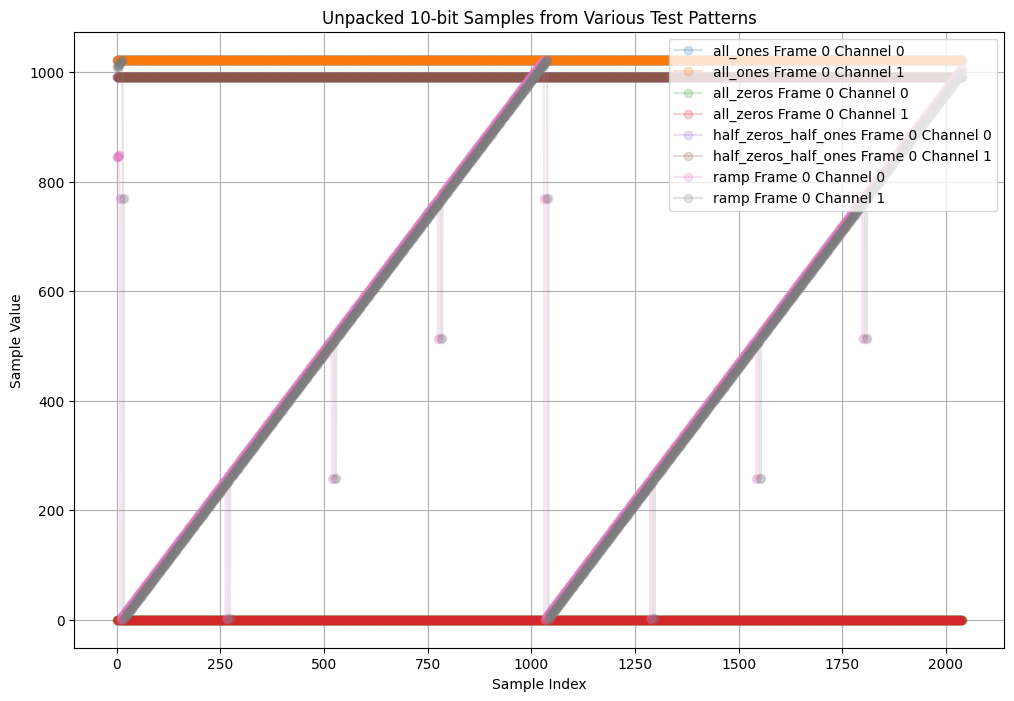

In [14]:
import matplotlib.pyplot as plt
# %matplotlib widget


plt.figure(figsize=(12, 8))

for name, data in [
    ("all_ones", data_all_ones),
    ("all_zeros", data_all_zeros),
    ("half_zeros_half_ones", data_half_zeros_half_ones),
    ("ramp", data_ramp),
    # ("toggle", data_toggle),
    # ("real", data_real),
]:
    data_parsed = parse_bitstream_numba(np.frombuffer(data, dtype=np.uint8), num_shots, num_frames, fifo_depth, np.array(lvds_lanes, dtype=np.int32))
    # data_parsed = parse_bitstream_numpy(np.frombuffer(data, dtype=np.uint8), num_shots, num_frames, fifo_depth, np.array(lvds_lanes, dtype=np.int32))

    # for frame in range(data_parsed.shape[0]):
    for frame in range(1):
        for channel in range(data_parsed.shape[2]):
        # for channel in range(1):
            plt.plot(data_parsed[frame, 0, channel], 'o-', alpha=0.2, label=f"{name} Frame {frame} Channel {channel}")

plt.title("Unpacked 10-bit Samples from Various Test Patterns")
plt.xlabel("Sample Index")
plt.ylabel("Sample Value")
# plt.xlim(1000, 1110)
plt.legend(loc='upper right')
plt.grid()
plt.show()

Initilal length of byte array:  80040
Aligned  length of byte array:  5120
Shape of bit array:  (1, 40960)
Trimmed shape of bit array:  (1, 40960)
Cut from the start n samples, n = :  1
Cut from the end n samples, n = :  0
Bit slip corrected number of bits per lane:  40940
N of acquired samples:  2047


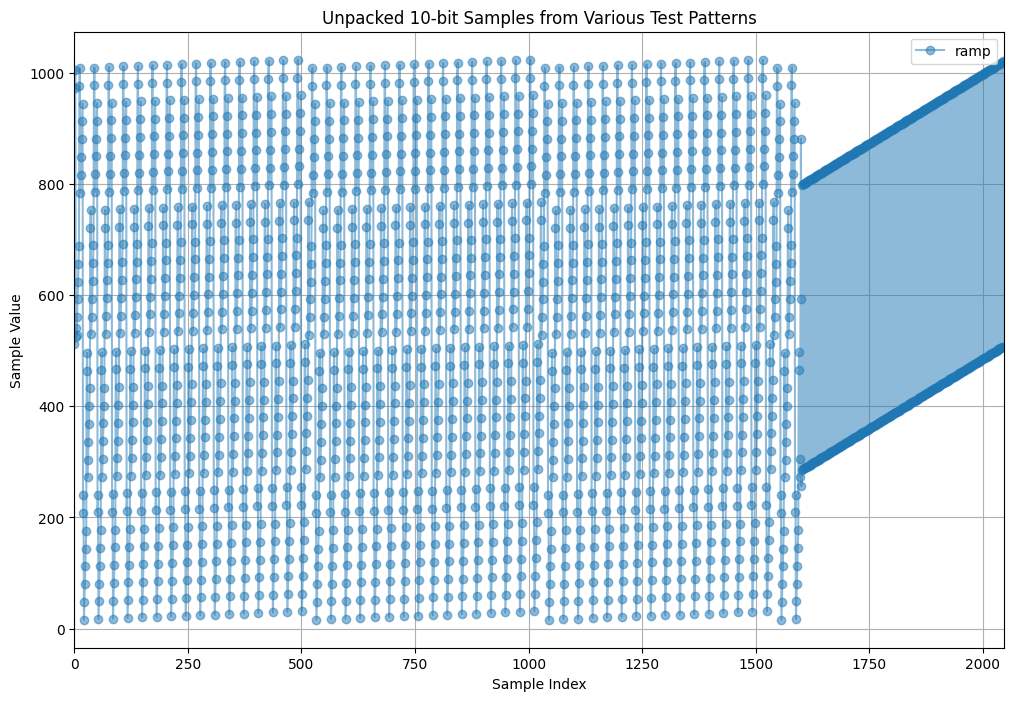

In [13]:
from parser import parse_bitstream_original

plt.figure(figsize=(12, 8))

for name, data in [
    # ("all_ones", data_all_ones),
    # ("all_zeros", data_all_zeros),
    # ("half_zeros_half_ones", data_half_zeros_half_ones),
    ("ramp", data_ramp),
    # ("toggle", data_toggle),
]:
    samples = parse_bitstream_original(data, dbg_msgs=True, read_size_samples=fifo_depth, n_activ_ch=len(lvds_lanes)*2)
    plt.plot(samples[0], 'o-', label=name, alpha=0.5)

plt.title("Unpacked 10-bit Samples from Various Test Patterns")
plt.xlabel("Sample Index")
plt.ylabel("Sample Value")
plt.xlim(0, 2048)
plt.legend(loc='upper right')
plt.grid()
plt.show()